# One Country, Too Many Nations — Companion Data

Reproducible data and code for the Ahmadi Research blog post
**"One Country, Too Many Nations: What America Got Wrong in Afghanistan"**.

- Live post: https://ahmadiresearch.com/blog/one-country-too-many-nations/
- Author: Mohammad Ahmadi
- Original class paper (Tufts, EC 184, May 2025): **not included** in this public package by design.

This notebook contains every data point used in the blog post, cited inline. Run the cells in order
to reproduce all four charts. Every assumption is written down — change it, rerun, and see what breaks.
That is the point.

> *"If someone with the same data can't get to the same conclusion, the analysis isn't done."* — Ahmadi Research, "Show Your Work"


## Setup

```bash
pip install -r requirements.txt
jupyter notebook Afghanistan_Data.ipynb
```

Dependencies: `pandas`, `numpy`, `matplotlib`. No proprietary data, no black boxes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Brand palette (matches the blog post)
BRAND = {
    'blue_main':   '#005a96',
    'blue_soft':   '#0f80c4',
    'blue_light':  '#8fd1ff',
    'title_blue':  '#13597B',
    # Atlas palette for ethnic regions (Chart 2)
    'pashtun':  '#2c6c91',
    'tajik':    '#c2941c',
    'hazara':   '#9c4869',
    'uzbek':    '#5d8a5e',
    'turkmen':  '#d39559',
    'aimaq':    '#8c7aae',
    'baluch':   '#b15c47',
    # Outcome palette for Chart 4
    'stable':    '#5d8a5e',
    'mixed':     '#c2941c',
    'collapsed': '#b15c47',
}

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['axes.axisbelow'] = True


---

## Chart 1 — Marshall Plan vs. Afghanistan Reconstruction

Both nominal and inflation-adjusted to 2024 USD.

**Data**

| Program       | Countries | Years     | Nominal ($B) | 2024 USD ($B) | Outcome             |
|---------------|-----------|-----------|--------------|---------------|---------------------|
| Marshall Plan | 16        | 1948–1952 | 13.3         | ~150          | Stable democracies  |
| Afghanistan   | 1         | 2001–2021 | ~2,313       | ~2,600        | State collapse      |

**Sources**

- Marshall Plan: National Museum of American Diplomacy, *The Marshall Plan*. Sixteen OEEC recipients
  (Austria, Belgium, Denmark, France, Greece, Iceland, Ireland, Italy, Luxembourg, Netherlands, Norway,
  Portugal, Sweden, Turkey, UK, West Germany). $13.3B nominal converts to ~$150B in 2024 dollars.
- Afghanistan: Costs of War Project, Watson Institute, Brown University. Cumulative U.S. spending of
  $2.313T through fiscal-year 2021 reporting, mixing year-of-spending dollars (2001–2021). Adjusting
  the weighted-average year (~2012) to 2024 yields roughly $2.6T in 2024 dollars (~+12%, BLS CPI).

**Assumptions you can argue with**
1. The Brown $2.3T figure includes Pentagon ops, State Dept, vets care to date, and interest on war
   borrowing — but excludes future veterans care (~$2.2T projected to 2050+). Including future vets
   care pushes the total closer to $4.5T.
2. The 2024-dollar adjustment uses a single weighted-average year. A year-by-year deflation would be
   more precise but doesn't materially change the ratio.


In [2]:
spend = pd.DataFrame({
    'Program':      ['Marshall Plan', 'Afghanistan'],
    'Countries':    [16, 1],
    'Years':        ['1948-1952', '2001-2021'],
    'Nominal_B':    [13.3, 2313.0],
    'Real2024_B':   [150.0, 2600.0],
    'Outcome':      ['Stable democracies', 'State collapse'],
})
spend['Per_Country_2024_B'] = spend['Real2024_B'] / spend['Countries']
spend['Ratio_to_Marshall_Real'] = spend['Real2024_B'] / spend.loc[0, 'Real2024_B']
spend


,Program,Countries,Years,Nominal_B,Real2024_B,Outcome,Per_Country_2024_B,Ratio_to_Marshall_Real
0,Marshall Plan,16,1948-1952,13.3,150.0,Stable democracies,9.375,1.000000
1,Afghanistan,1,2001-2021,2313.0,2600.0,State collapse,2600.000,17.333333


<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:14: SyntaxWarning: invalid escape sequence '\$'
<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:14: SyntaxWarning: invalid escape sequence '\$'
C:\Users\mahmad10\AppData\Local\Temp\ipykernel_45148\3327058674.py:12: SyntaxWarning: invalid escape sequence '\$'
  f"\${row['Nominal_B']:,.0f}B", va='center', fontsize=9, color='#374151')
C:\Users\mahmad10\AppData\Local\Temp\ipykernel_45148\3327058674.py:14: SyntaxWarning: invalid escape sequence '\$'
  f"\${row['Real2024_B']:,.0f}B", va='center', fontsize=9, color='#111827', fontweight='bold')


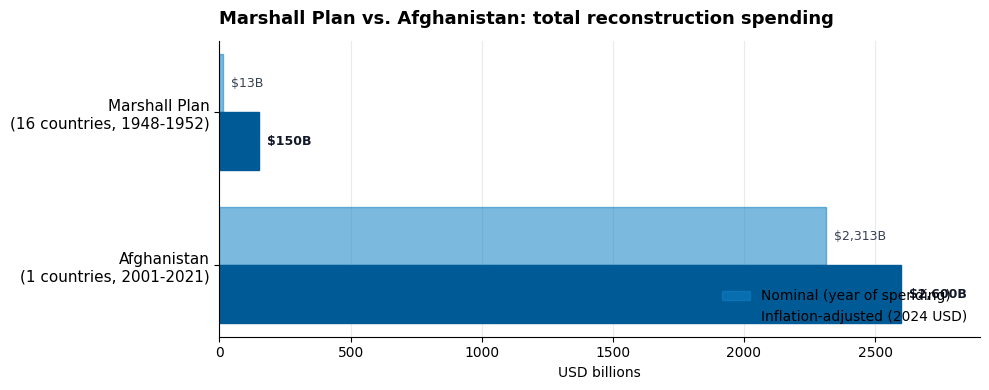


Ratio (real 2024 dollars): Afghanistan / Marshall = 17.3x


In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
y = np.arange(len(spend))
h = 0.38

ax.barh(y - h/2, spend['Nominal_B'], h, label='Nominal (year of spending)',
        color=BRAND['blue_soft'], alpha=0.55, edgecolor=BRAND['blue_soft'])
ax.barh(y + h/2, spend['Real2024_B'], h, label='Inflation-adjusted (2024 USD)',
        color=BRAND['blue_main'], edgecolor=BRAND['blue_main'])

for i, row in spend.iterrows():
    ax.text(row['Nominal_B'] + 30, i - h/2,
            f"\${row['Nominal_B']:,.0f}B", va='center', fontsize=9, color='#374151')
    ax.text(row['Real2024_B'] + 30, i + h/2,
            f"\${row['Real2024_B']:,.0f}B", va='center', fontsize=9, color='#111827', fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels([f"{p}\n({c} countries, {yr})" for p,c,yr in
                    zip(spend['Program'], spend['Countries'], spend['Years'])],
                   fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('USD billions')
ax.set_xlim(0, 2900)
ax.set_title('Marshall Plan vs. Afghanistan: total reconstruction spending',
             loc='left', fontsize=13, fontweight='600', pad=12)
ax.legend(loc='lower right', frameon=False, fontsize=10)
ax.grid(axis='x', alpha=0.25)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

print(f"\nRatio (real 2024 dollars): Afghanistan / Marshall = "
      f"{spend.loc[1,'Real2024_B'] / spend.loc[0,'Real2024_B']:.1f}x")


---

## Chart 2 — Estimated Ethnic Composition of Afghanistan

No national census in Afghanistan since 1979. All shares are estimates. Source: Minority Rights Group
International, *Afghanistan* country profile.

**Note on the live post:** the blog version replaces this stacked bar with a stylized SVG map of
Afghanistan showing where each group lives, plus the Hindu Kush mountain spine. The map is built from
the Afghanistan country outline at github.com/djaiss/mapsicon (MIT-licensed) with the same percentages
shown below. The bar chart here is the cleanest reproducible form for the underlying numbers.


In [4]:
ethnic = pd.DataFrame([
    {'group': 'Pashtun',  'share_pct': 42, 'homeland': 'South & east (Kandahar, Helmand, Khost, Nangarhar)'},
    {'group': 'Tajik',    'share_pct': 27, 'homeland': 'Northeast (Badakhshan, Panjshir), Wakhan, Herat, Kabul enclave'},
    {'group': 'Hazara',   'share_pct': 9,  'homeland': 'Central highlands (Bamyan, Daikundi, parts of Ghor)'},
    {'group': 'Uzbek',    'share_pct': 9,  'homeland': 'Northern plains (Faryab, Jowzjan, parts of Balkh)'},
    {'group': 'Aimaq',    'share_pct': 4,  'homeland': 'West-central (Ghor, Badghis)'},
    {'group': 'Turkmen',  'share_pct': 3,  'homeland': 'Northwest (Faryab, Jowzjan)'},
    {'group': 'Baluch',   'share_pct': 2,  'homeland': 'Southwest (Nimroz)'},
    {'group': 'Other',    'share_pct': 4,  'homeland': 'Nuristani, Pashai, others (eastern mountains)'},
])
print(f"Total: {ethnic['share_pct'].sum()}%")
ethnic


Total: 100%


,group,share_pct,homeland
0,Pashtun,42,"South & east (Kandahar, Helmand, Khost, Nangar..."
1,Tajik,27,"Northeast (Badakhshan, Panjshir), Wakhan, Hera..."
2,Hazara,9,"Central highlands (Bamyan, Daikundi, parts of ..."
3,Uzbek,9,"Northern plains (Faryab, Jowzjan, parts of Balkh)"
4,Aimaq,4,"West-central (Ghor, Badghis)"
5,Turkmen,3,"Northwest (Faryab, Jowzjan)"
6,Baluch,2,Southwest (Nimroz)
7,Other,4,"Nuristani, Pashai, others (eastern mountains)"


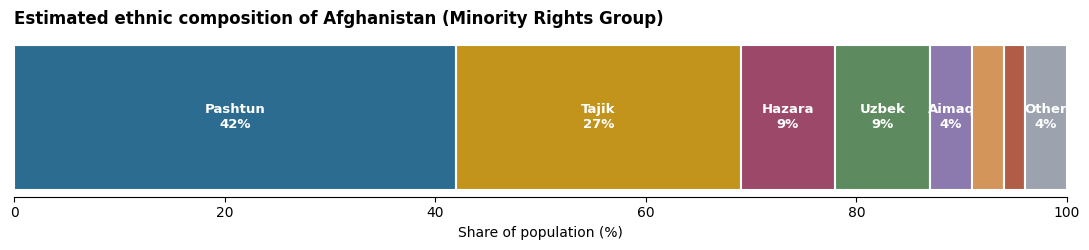

In [5]:
palette_order = ['pashtun','tajik','hazara','uzbek','aimaq','turkmen','baluch']
colors = [BRAND[k] for k in palette_order] + ['#9ca3af']  # 'Other' = neutral gray

fig, ax = plt.subplots(figsize=(11, 2.6))
left = 0
for i, row in ethnic.iterrows():
    ax.barh(0, row['share_pct'], left=left, color=colors[i], edgecolor='white', linewidth=1.5)
    if row['share_pct'] >= 4:
        ax.text(left + row['share_pct']/2, 0,
                f"{row['group']}\n{row['share_pct']}%",
                ha='center', va='center', fontsize=9.5, color='white', fontweight='600')
    left += row['share_pct']

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel('Share of population (%)')
ax.set_title('Estimated ethnic composition of Afghanistan (Minority Rights Group)',
             loc='left', fontsize=12, fontweight='600', pad=10)
ax.spines['left'].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()


---

## Chart 3 — Pashtun Rule Timeline, 1747 – 2021

Of the ~274 years between Ahmad Shah Durrani's founding of the Durrani Empire (1747) and the
republic's collapse (2021), Pashtun-led leadership held power for roughly 269 years. Two brief Tajik
exceptions:

- **Habibullah Kalakani** — Tajik, ruled Jan 17 – Oct 13, 1929 (~9 months). Source: Al Jazeera 2016
  burial article.
- **Burhanuddin Rabbani** — Tajik, president of Islamic State of Afghanistan 1992–1996 (~4 years).
  Source: Minority Rights Group.

Periods 1929–1992 and 1996–2021 include both Pashtun monarchs/presidents and Pashtun-dominated
movements (PDPA leaders mostly Pashtun, Taliban Emirate predominantly Pashtun, US-backed republic
under Karzai and Ghani both Pashtun).


In [6]:
timeline = pd.DataFrame([
    {'segment': 'Pashtun rule',                'start': 1747,        'end': 1929 + 1/12,  'group': 'Pashtun'},
    {'segment': 'Kalakani (Tajik)',            'start': 1929 + 1/12, 'end': 1929 + 10/12, 'group': 'Tajik'},
    {'segment': 'Pashtun-led rule',            'start': 1929 + 10/12,'end': 1992.33,      'group': 'Pashtun'},
    {'segment': 'Rabbani (Tajik)',             'start': 1992.33,     'end': 1996.75,      'group': 'Tajik'},
    {'segment': 'Pashtun-led rule (Taliban + republic)', 'start': 1996.75, 'end': 2021.62, 'group': 'Pashtun'},
])
timeline['years'] = timeline['end'] - timeline['start']
timeline


,segment,start,end,group,years
0,Pashtun rule,1747.000000,1929.083333,Pashtun,182.083333
1,Kalakani (Tajik),1929.083333,1929.833333,Tajik,0.750000
2,Pashtun-led rule,1929.833333,1992.330000,Pashtun,62.496667
3,Rabbani (Tajik),1992.330000,1996.750000,Tajik,4.420000
4,Pashtun-led rule (Taliban + republic),1996.750000,2021.620000,Pashtun,24.870000


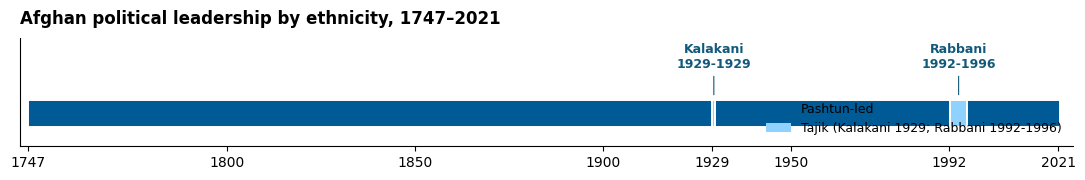


Pashtun-led rule: 269.4 of 274.6 years (98.1%)


In [7]:
fig, ax = plt.subplots(figsize=(11, 1.9))
group_colors = {'Pashtun': BRAND['blue_main'], 'Tajik': BRAND['blue_light']}

for _, row in timeline.iterrows():
    ax.barh(0, row['years'], left=row['start'], height=0.5,
            color=group_colors[row['group']], edgecolor='white', linewidth=1.4)

# Annotate Tajik exceptions
for _, row in timeline.iterrows():
    if row['group'] == 'Tajik':
        ax.annotate(f"{row['segment'].split('(')[0].strip()}\n{int(row['start'])}-{int(row['end'])}",
                    xy=(row['start'] + row['years']/2, 0.3),
                    xytext=(row['start'] + row['years']/2, 0.85),
                    ha='center', fontsize=9, color='#13597B', fontweight='600',
                    arrowprops=dict(arrowstyle='-', color='#13597B', lw=0.8))

ax.set_xlim(1745, 2025)
ax.set_ylim(-0.6, 1.4)
ax.set_yticks([])
ax.set_xticks([1747, 1800, 1850, 1900, 1929, 1950, 1992, 2021])
ax.set_xticklabels(['1747', '1800', '1850', '1900', '1929', '1950', '1992', '2021'])
ax.set_title('Afghan political leadership by ethnicity, 1747–2021',
             loc='left', fontsize=12, fontweight='600', pad=10)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=BRAND['blue_main'], label='Pashtun-led'),
                   Patch(facecolor=BRAND['blue_light'], label='Tajik (Kalakani 1929; Rabbani 1992-1996)')],
          loc='lower right', frameon=False, fontsize=9)
ax.grid(False)
plt.tight_layout()
plt.show()

pashtun_years = timeline[timeline['group']=='Pashtun']['years'].sum()
total_years   = timeline['years'].sum()
print(f"\nPashtun-led rule: {pashtun_years:.1f} of {total_years:.1f} years "
      f"({100*pashtun_years/total_years:.1f}%)")


---

## Chart 4 — Federalism vs. Post-Conflict Stability

A 0–5 author scoring across five multi-ethnic states. The point isn't that the scores are precise —
it's that the *pattern* across cases is what the comparative literature predicts: federalism alone is
not sufficient (Yugoslavia, Ethiopia), but its absence in a polarized society is reliably
destabilizing (Afghanistan).

**Scoring rubric**

- **Federalism** (0 = unitary, 3 = decentralized w/ partial autonomy, 5 = strong ethnic/linguistic
  federalism with real subnational policy authority)
- **Stability** (0 = state collapse, 2 = persistent civil conflict, 4 = stable with managed
  ethnic tensions, 5 = stable)

| Country              | Federalism | Stability | Outcome   | Justification |
|----------------------|------------|-----------|-----------|---------------|
| India                | 5          | 4         | Stable    | 1956 States Reorganization Act; linguistic states; no group >40%[Britannica] |
| Iraq                 | 3          | 2         | Mixed     | 2005 constitution recognizes KRG; Sunni-Shia civil war + ISIS[Aziz, EISMENA 2023] |
| Ethiopia             | 4          | 2         | Mixed     | 1991 ethnic federalism; Tigray war[Habtu 2003; Ottaway, Wilson 2021] |
| Yugoslavia (1991)    | 3          | 0         | Collapsed | Tito's federation; collapsed once authoritarian glue dissolved[Critchley 1993] |
| Afghanistan (2021)   | 1          | 0         | Collapsed | Highly centralized 2004 constitution; Pashtun-dominated state[Thier USIP 2020; Diplomat 2021] |


In [8]:
cases = pd.DataFrame([
    {'country': 'India',              'federalism': 5, 'stability': 4, 'outcome': 'stable'},
    {'country': 'Iraq',               'federalism': 3, 'stability': 2, 'outcome': 'mixed'},
    {'country': 'Ethiopia',           'federalism': 4, 'stability': 2, 'outcome': 'mixed'},
    {'country': 'Yugoslavia (1991)',  'federalism': 3, 'stability': 0, 'outcome': 'collapsed'},
    {'country': 'Afghanistan (2021)', 'federalism': 1, 'stability': 0, 'outcome': 'collapsed'},
])
cases


,country,federalism,stability,outcome
0,India,5,4,stable
1,Iraq,3,2,mixed
2,Ethiopia,4,2,mixed
3,Yugoslavia (1991),3,0,collapsed
4,Afghanistan (2021),1,0,collapsed


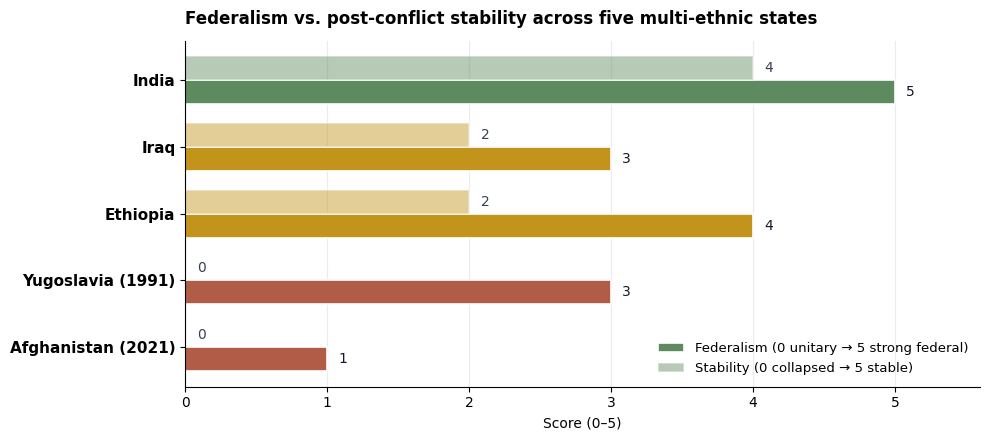

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5))
y = np.arange(len(cases))[::-1]
h = 0.36

# Color each row by outcome (atlas-palette greens/ambers/reds)
outcome_color = {'stable': BRAND['stable'], 'mixed': BRAND['mixed'], 'collapsed': BRAND['collapsed']}
fed_colors  = [outcome_color[o] for o in cases['outcome']]
stab_colors = fed_colors  # same hue, lighter alpha applied below

ax.barh(y - h/2, cases['federalism'], h, color=fed_colors, edgecolor='white', linewidth=1.2,
        label='Federalism (0 unitary → 5 strong federal)')
ax.barh(y + h/2, cases['stability'], h, color=fed_colors, edgecolor='white', linewidth=1.2,
        alpha=0.45, label='Stability (0 collapsed → 5 stable)')

for i, row in cases.iterrows():
    yi = y[i]
    ax.text(row['federalism'] + 0.08, yi - h/2, str(row['federalism']), va='center', fontsize=10, color='#111827')
    ax.text(row['stability']  + 0.08, yi + h/2, str(row['stability']),  va='center', fontsize=10, color='#374151')

ax.set_yticks(y)
ax.set_yticklabels(cases['country'], fontsize=11, fontweight='600')
ax.set_xlim(0, 5.6)
ax.set_xticks(range(6))
ax.set_xlabel('Score (0–5)')
ax.set_title('Federalism vs. post-conflict stability across five multi-ethnic states',
             loc='left', fontsize=12, fontweight='600', pad=12)
ax.legend(loc='lower right', frameon=False, fontsize=9.5)
ax.grid(axis='x', alpha=0.25)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()


---

## Sources

Numbered to match the live blog post.

1. National Museum of American Diplomacy — *The Marshall Plan*. https://diplomacy.state.gov/online-exhibits/diplomacy-is-our-mission/development/the-marshall-plan/
2. Costs of War Project, Watson Institute, Brown University — *Costs of the 20-year war on terror: $8 trillion and 900,000 deaths*, Brown News, September 1, 2021. https://www.brown.edu/news/2021-09-01/costsofwar; current figures at https://costsofwar.watson.brown.edu/findings
3. Gareth Price, Chatham House — *Why Afghan Nation-Building Was Always Destined to Fail*, September 10, 2021. https://www.chathamhouse.org/2021/09/why-afghan-nation-building-was-always-destined-fail
4. Graeme Herd, George C. Marshall European Center for Security Studies — *The Causes and the Consequences of Strategic Failure in Afghanistan*, August 2021. https://www.marshallcenter.org/en/publications/security-insights/causes-and-consequences-strategic-failure-afghanistan-0
5. Alex Thier, U.S. Institute of Peace — *The Nature of the Afghan State: Centralization vs. Decentralization*, 2020. https://www.usip.org/sites/default/files/Afghanistan-Peace-Process_Nature-of-the-Afghan-State_Centralization-vs-Decentralization.pdf
6. Alesina & Spolaore, *The Size of Nations*, MIT Press, 2003; Alesina, *The Size of Countries: Does It Matter?*, JEEA 2003. https://dash.harvard.edu/handle/1/4551794
7. Enrico Spolaore — *Federalism, Regional Redistribution, and Country Stability*, Tufts Working Paper, 2008; Bakke & Wibbels, *Diversity, Disparity, and Civil Conflict in Federal States*, World Politics 2006.
8. Montalvo & Reynal-Querol — *Ethnic Polarization, Potential Conflict, and Civil Wars*, AER 2005.
9. Minority Rights Group International — *Afghanistan*, 2024. https://minorityrights.org/country/afghanistan/
10. Fernández-Villaverde, Koyama, Lin & Sng — *The Fractured-Land Hypothesis and State Formation in Eurasia*, 2022.
11. United Nations — *Bonn Agreement on Provisional Arrangements in Afghanistan*, December 5, 2001.
12. Al Jazeera — *Kabul burial of Tajik King Kalakani stirs tension*, September 2, 2016.
13. Jennifer Brick Murtazashvili — *The Collapse of Afghanistan*, Journal of Democracy, 2022.
14. Middle East Institute — *Taliban Leadership Tracker, Demographics*, 2024 (1,212 senior officials, ~90% Pashtun). https://talibantracker.mei.edu/english/taliban/demographics
15. Encyclopedia Britannica — *States Reorganization Act*.
16. Sardar Aziz, EISMENA — *Iraqi Federalism: The Second-Best Option for Everyone*, October 25, 2023.
17. Alem Habtu — *Ethnic Federalism in Ethiopia*, 2003.
18. David Ottaway, Wilson Center — *Ethiopia Faces Dire Consequences of Ethnic Federalism*, July 28, 2021.
19. W. Harriet Critchley — *The Failure of Federalism in Yugoslavia*, International Journal, 1993.
20. Jamestown Foundation — *The Warlords Return to Afghanistan: Atta Mohammad Noor*, 2021; Carter Malkasian, *The American War in Afghanistan: A History* (Oxford, 2021).
21. France 24 / AFP — *Afghan warlords give up to the Taliban with surprising ease*, August 15, 2021.
22. The Diplomat — *Ashraf Ghani and the Pashtun Dilemma*, January 2015; USIP — *One Year Later: Taliban Reprise Repressive Rule*, August 2022.

---

*Companion data for "One Country, Too Many Nations: What America Got Wrong in Afghanistan."
Released under MIT for code, CC-BY-4.0 for data and prose. The original class paper is not part
of this public package.*
